# RF Link Budget
---

A link budget is a power-based analysis that meticulously accounts for all signal gains and losses, as well as noise contributions, across the entire communication path, from the transmitter to the receiver. This analysis is essential for determining the required transmit power, selecting appropriate antennas, and assessing the impact of the propagation environment. The link budget is sometimes expressed as a carrier-to-noise ratio (CNR). But to determine if the link closes Eb/N0 is needed to relate the data accuracy metric bit error rate (BER) to the signal quality metric carrier-to-noise ratio (CNR).

[Eb/N0](https://en.wikipedia.org/wiki/Eb/N0) (Energy per bit to Noise power spectral density) serves as a key figure of merit in this design process, providing a standardized measure of signal quality that allows for the universal comparison of different modulation schemes (e.g., BPSK, QAM), coding techniques (e.g., convolutional codes, LDPC), and system designs under identical noise conditions. This universal comparison enables engineers to evaluate and optimize system performance across various scenarios, independent of specific hardware implementations or channel characteristics. By carefully considering the link budget and optimizing for Eb/No, engineers can ensure that the received signal strength is sufficient to overcome noise and interference, ultimately achieving the desired data throughput and quality.

The required Eb/N0 can be found from different sources. The following resource can be used to calculate the M-ary bit error rate (BER) for a phase-shift keying scheme (PSK) signal over an additive white Gaussian noise channel.

1. Jianhua Lu, K. B. Letaief, J. C. . -I. Chuang and M. L. Liou, "M-PSK and M-QAM BER computation using signal-space concepts," in IEEE Transactions on Communications, vol. 47, no. 2, pp. 181-184, Feb. 1999, doi: 10.1109/26.752121.

The required Eb/N0 can than be used to derived the necessary Carrier-to-Noise CNR ratio by

$$
\begin{equation}
\frac{C}{N}=\frac{E_b}{N_0}\frac{R}{B}
\end{equation}
$$

where
* $R$ is the channel data rate (bit rate)
* $B$ is the channel bandwidth

Example BERs for a few M-ary QAM signals are shown below. Check out [spacelink](https://github.com/cascade-space-co/spacelink) for a large set of performance curves.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from IPython.display import Markdown, HTML, display

from xcvr.linkbudget import LinkBudget
from xrench.units import ureg
from xcvr.ber import mqam_ber


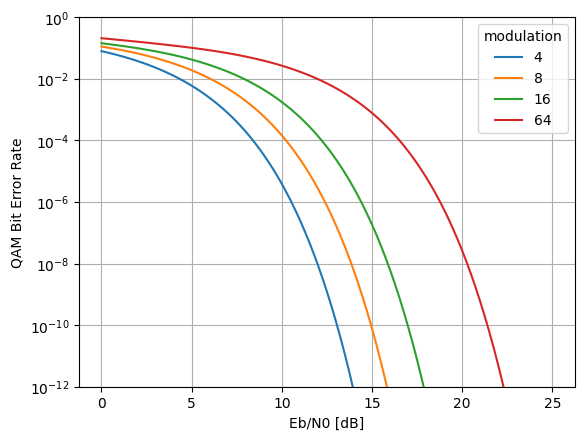

In [2]:
ebno = xr.DataArray(
    np.linspace(0, 25, 101) * ureg.dB, dims=("ebno",), coords=dict(ebno=np.linspace(0, 25, 101))
)
mqam = mqam_ber(ebno=ebno)
mod_dict = dict(modulation=2**mqam.modulation_order.values)
mqam = mqam.rename({"modulation_order": "modulation"})
mqam = mqam.assign_coords(mod_dict)

mqam.plot.line(x="ebno", yscale="log")
ax = plt.gca()
ax.set_xlabel("Eb/N0 [dB]")
ax.set_ylabel("QAM Bit Error Rate")
ax.set_ylim(10e-13, 1)
ax.grid(True);

Note that as the modulation order increases the Eb/N0 required increases to maintain the same Bit Error Rate (BER).

## Friis Transmission Equation
---

First, the RF link budget is easily derived for the carrier-to-noise ratio (CNR) by accounting for the signal power and noise terms. The signal power is given from the [Friis transmission equation](https://en.wikipedia.org/wiki/Friis_transmission_equation) 

$$
\begin{equation}
P_{r}=P_{t}G_{t}G_{r}\left(\frac{\lambda}{4\pi d}\right)^2
\end{equation}
$$

where 

| Symbol | Description |
|-:|:-|
| $P_r$ | Received power |
| $P_t$ | Transmit power at antenna terminals |
| $G_t$ | Transmit antenna gain towards receiver |
| $G_r$ | Receive antenna gain towards transmitter |
| $\lambda$ | Wavelength |
| $d$ | Distance between transmitter and receiver |

In practice the path loss term $\left(\lambda/4\pi d\right)^2$ can include more accurate models that account for atmospheric conditions, terrain, etc. In the link budget this term is accounted for by the $PL$ or path loss term. The equation can be written in decibel form assuming the powers are normalized to 1mW the decibel form is in dBm

$$
\begin{equation}
P_r\mathrm{[dBm]} = P_t\mathrm{[dBm]} + G_t\mathrm{[dB]} - PL\mathrm{[dB]} + G_r\mathrm{[dB]}
\end{equation}
$$

## System Noise Power
---

The noise power is equal to $kT_{sys}B$ where $T_{sys} = T_{ant} + T_0(F-1)$. For more information on antenna temperature. Assuming $T_{ant}=T_0$ yields a simple form for the system temperature $T_{sys} = T_0F$. The noise power in decibel milliwatts is written by

$$
\begin{equation}
P_n\mathrm{[dBm]} = kT_0\mathrm{[dBm/Hz]} + NF + B\mathrm{[dBHz]}
\end{equation}
$$

The carrier-to-noise ratio is now given by

$$
\begin{equation}
CNR = \frac{P_r}{P_n}=P_t\mathrm{[dBm]} + G_t\mathrm{[dB]} - PL\mathrm{[dB]} + G_r\mathrm{[dB]} - kT_0\mathrm{[dBm/Hz]} - NF - B\mathrm{[dBHz]}
\end{equation}
$$

Next solving for the Eb/No

$$
\begin{equation}
\frac{E_b}{N_0}=P_t\mathrm{[dBm]} + G_t\mathrm{[dB]} - PL\mathrm{[dB]} + G_r\mathrm{[dB]} - kT_0\mathrm{[dBm/Hz]} - NF - R\mathrm{[dBbits/s]}
\end{equation}
$$

noticing that the bandwidth terms cancel out. Now the link margin can be solved shown in decibel form below

* The required EbNo is solved given the modulation and desired maximum bit error rate.
* The link margin is then solved with the following relation from carrier-to-noise ratio (CNR) to the EbNo

Note the noise power is equal to $kT_{sys}B$ where $T_{sys} = T_{ant} + T_0(F-1)$. Assuming $T_{ant}=T_0$ yields a simple form for the system temperature $T_{sys} = T_0F$. Now the link margin can be solved shown in decibel form below

$$
\begin{equation}
\mathrm{Margin}\mathrm{[dB]} = P_t\mathrm{[dB]} + G_t\mathrm{[dB]} - PL\mathrm{[dB]} + G_r\mathrm{[dB]} - kT_0\mathrm{[dB]} - NF\mathrm{[dB]} - R\mathrm{[dB]} - (E_b/N_0)_{\mathrm{req}}\mathrm{[dB]}
\end{equation}
$$

The link margin table is shown below

# Receiver Clarity and G/T
---

RF system designers dislike it and system integrators rely on it to verify link closure - G/T can be a controversial figure of merit. The receiver is where signal meets noise, and one unavoidable figure of merit describes the clarity of the receiver as the ratio of the antenna gain to system noise temperature. I find the easiest description is a gain normalized receiver noise term. It can be a frustrating figure of merit because it depends on external factors like apparent sky temperature and deals with antenna efficiency which can be difficult to measure.

Designers are will generally lean towards antenna gain and receiver noise figure as concrete metrics to design towards, but those are only pieces of the G/T equation.

# Reference Plane
---

G/T (G over T) is a figure of merit for receive terminals. However, because of the ratio, it can be confusing to estimate. With it, the CNR can be determined by simply knowing transmit EIRP and path loss or isotropic received power. G/T can be difficult to estimate because it requires knowing the aparent sky temperature, antenna efficiency, and receiver temperature. Depending on the reference plane used the gain and temperature terms will be scaled, but the ratio remains invariant. This reference plane varies depending on how the antenna and receiver is characterized. For illustration purposes consider three reference planes illustrated below.

![](images/govert.png)

1. Aperture plane: Fictitious surface to that accounts for the signal gain via the antenna directivity, but prior to losses in the antenna
2. Antenna terminals: Where the antenna gain is measured at the connector
3. Receiver terminals: Where the receiver connector

Note, this example considers three components: antenna, a lossy cable, and receiver. RF systems may integrate all of these components into a single PCB, but this example still holds. Illustrating how measurements at different reference planes will result in the same G/T assuming proper accounting of losses in the antenna, feed line, and receiver noise temperature.

## Terms

In the following sections, the G/T will be derived at each reference plane.
The antenna is characterized by a directivity towards the transmitter as $D$, a radation efficiency $\eta$, and an antenna radiometric temperature $T_A$. The following terminology is used for this derivation.

| Symbol | Description |
|:-|:-|
| $NF$ | Noise figure in decibals |
| $F$ | Noise factor (linear form of noise figure) |
| $G(\theta,\phi)$ | Antenna gain |
| $\eta$ | Antenna radiation efficiency |
| $D(\theta,\phi)$ | Antenna directivity |
| $T_{AP}(\theta,\phi)$ | Spatially dependent apparent temperature distribution |
| $T_A$ | Antenna radiometric temperature |
| $L$ | Loss in the network connecting the antenna to the receiver like from that of a cable |

The antenna temperature is given by
$$
\begin{align}
T_A=\frac{\int\int T_{AP}(\theta,\phi)D(\theta,\phi)d\Omega}{\int\int D(\theta,\phi)d\Omega}
\end{align}
$$

Noise temperatures are defined as equivalent **input-referred** noise temperatures and are related to the noise factor $F$ by
$$
\begin{align}
T_e=T_0(F-1)
\end{align}
$$
Where $T_0$ is the reference temperature.
referring to noise figure $NF$ is the noise factor $F$ in decibels: $NF=10\log(F)$

### Passive Loss and Noise Temperature

A note on the term loss: for a passive network, loss is defined as a value greater than one when the network is *lossy*, whereas gain terms, such as antenna efficiency $\eta$, are less than one. Gain and loss are related by

$$
\begin{align}
G=\frac{1}{L}
\end{align}
$$

Passive loss also implies the generation of thermal noise. The output noise temperature of a lossy network consists of the input noise attenuated by the loss, plus thermal noise generated by the network itself:
$$
\begin{align}
T_{out} = \frac{1}{L}T_{in}+\left(1-\frac{1}{L}\right)T_0 = \eta T_{in}+(1-\eta)T_0
\end{align}
$$
where $T_0$ is the physical temperature of the lossy network.

To determine the equivalent **input‑referred** noise temperature when the output temperature is known, the Friis noise transformation is used:
$$
\begin{align}
T_{E} =LT_{out}+\left(L-1\right)T_0 = \frac{1}{\eta} T_{out}+\left(\frac{1}{\eta}-1\right)T_0
\end{align}
$$

This formulation allows noise temperatures to be consistently referred to any chosen reference plane. With these definitions established, G/T can be derived at each reference plane, starting at the antenna aperture, to show explicitly how the gain and noise terms change while the ratio remains invariant.

## Aperture Plane
$$
\begin{align}
G/T = \frac{D}{T_{sys}}=\frac{D}{T_A+ T_{rec}''}
\end{align}
$$
For the aperture plane, the gain is given by the directivity and the antenna temperature is also defined at this plane, but the receiver temperature needs to be defined at the aperture terminals.
$$
\begin{align}
T_{\mathrm{rec}}'' = \frac{1}{\eta}\left(LT_{\mathrm{rec}}+ (L-1)T_0- (1-\eta)T_0\right) 
\end{align}
$$

Giving
$$
\begin{align}
G/T = \frac{D}{T_A+ \frac{1}{\eta}\left(LT_{\mathrm{rec}}+ (L-1)T_0- (1-\eta)T_0\right) }
\end{align}
$$

which can be written with the $G=\eta D$ term in the numerator as
$$
\begin{align}
G/T = \frac{\eta D}{\eta \left(T_A-T_0\right)+ L\left(T_{\mathrm{rec}}+T_0\right)}
\end{align}
$$

## Antenna Terminals
$$
\begin{align}
G/T = \frac{\eta D}{T_A'+ T_{rec}'}
\end{align}
$$
The numerator is the signal portion given from the efficiency and directivity as $\eta D$
The noise temperature is the summation of the contribution from the antenna and receiver

The antenna temperature at this reference plane is $T_A'$

$$
\begin{align}
T_A' = \eta T_A+ (1-\eta)T_0
\end{align}
$$

Similarly, the receiver temperature $T_{\mathrm{rec}}$ needs to be transformed to the antenna terminals reference plane
$$
\begin{align}
T_{\mathrm{rec}}' = LT_{\mathrm{rec}}+ (L-1)T_0
\end{align}
$$

The gain is given by the directivity and efficiency as $G=\eta D$. So the G/T ratio at the antenna terminals is

$$
\begin{align}
G/T = \frac{\eta D}{\eta \left(T_A-T_0\right)+ L\left(T_{\mathrm{rec}}+T_0\right)} 
\end{align}
$$

## Receiver Terminals
$$
\begin{align}
G/T = \frac{\eta D/L}{T_A''+ T_{rec}}
\end{align}
$$
The antenna temperature at the input of the receiver is
$$
\begin{align}
T_A'' = \frac{1}{L} T_A'+ (1-\frac{1}{L})T_0 = \frac{1}{L}\left(\eta T_A+ (1-\eta)T_0\right)+(1-\frac{1}{L})T_0
\end{align}
$$

Giving, the G/T as
$$
\begin{align}
G/T = \frac{\eta D/L}{\frac{1}{L}\left(\eta T_A+ (1-\eta)T_0\right)+(1-\frac{1}{L})T_0 + T_{\mathrm{rec}}}
\end{align}
$$
which can be written with the $G=\eta D$ term in the numerator as
$$
\begin{align}
G/T =\frac{\eta D}{\eta \left(T_A-T_0\right)+ L\left(T_{\mathrm{rec}}+T_0\right)} 
\end{align}
$$

Showing that at each reference plane the overall ratio is the same.

# Simplifications

A frustrating characteristic of $G/T$ is its dependence on the environment. This will impact $T_{AP}$ and $T_0$. So $G/T$ isn't an inherent characteristic of the receiver. Noise figure is an inherent charateristic, that can be used to determine temperature from the reference or physical temperature.

Ok I know at the beginning we said it was unavoidable, there are some simplifications that make characterizing it much easier. One of the biggest simplifications can be to assuming that everything is at the reference temperature $T_A=T_0$ which is a good approximation for terrestrial systems. In that case, it simplifies to
$$
\begin{align}
G/T = \frac{\eta D}{L\left(T_0+ T_{\mathrm{rec}}\right)}
\end{align}
$$

simplifying to

$$
\begin{align}
G/T = \frac{\eta D}{L T_0 F}
\end{align}
$$

This has the huge benefit of enabling writing the of the link budget equation in decibels as:

$$
\begin{align}
CNR = \frac{P_r}{P_n}=P_t\mathrm{[dBm]} & + G_t\mathrm{[dB]} - FSPL\mathrm{[dB]} + G_r\mathrm{[dB]}\\
& - kT_0\mathrm{[dBm/Hz]} - L\mathrm{[dB]} - NF\mathrm{[dB]} - B\mathrm{[dBHz]}
\end{align}
$$

# References

1. https://en.wikipedia.org/wiki/Eb/N0
2. Jianhua Lu, K. B. Letaief, J. C. . -I. Chuang and M. L. Liou, "M-PSK and M-QAM BER computation using signal-space concepts," in IEEE Transactions on Communications, vol. 47, no. 2, pp. 181-184, Feb. 1999, doi: 10.1109/26.752121.
https://en.wikipedia.org/wiki/Friis_transmission_equation
3. C. A. Balanis, Antenna theory: analysis and design, 3. ed. Hoboken, N.J: Wiley-Interscience, 2005, pp. 104-108.
4. F. T. Ulaby, R. K. Moore, and A. K. Fung, Microwave remote sensing: active and passive. in Remote sensing. Volume 1. Norwood (Mass.): Artech house, 1981, pp. 203-208.
5. https://www.youtube.com/watch?v=Nes-e2oE7oo

In [3]:
eta = np.around(np.linspace(0.2, 0.8, 4), 1)
eta = xr.DataArray(eta, dims=("eta",), coords=dict(eta=eta))
ta = np.array([50, 100, 290, 500])
ta = xr.DataArray(ta, dims=("ta",), coords=dict(ta=ta))

t0 = 290
G_db = 30
g = 10 ** (G_db / 10)
nf = np.array([2, 5, 10])
nf = xr.DataArray(nf, dims=("nf",), coords=dict(nf=nf))
f = 10 ** (nf / 10)
trec = t0 * (f - 1)
govert = 10 * np.log10(g / (eta * (ta - t0) + (trec + t0)))
govert.attrs = dict(long_name="G/T", units="dB")

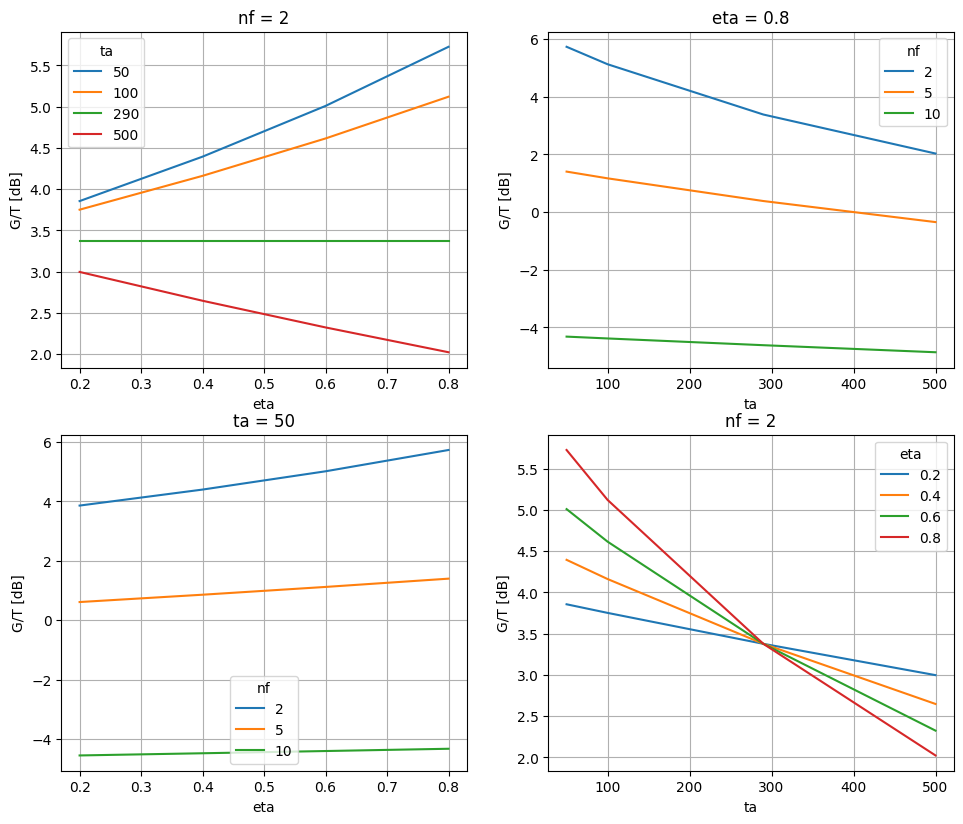

In [4]:
fig, ((ax0, ax1), (ax2, ax3)) = plt.subplots(ncols=2, nrows=2)
fig.set_figwidth(fig.get_figwidth() * 1.8)
fig.set_figheight(fig.get_figheight() * 2)
govert.sel(nf=2).plot.line(x="eta", ax=ax0)
govert.sel(ta=50).plot.line(x="eta", ax=ax2)
govert.sel(eta=0.8).plot.line(x="ta", ax=ax1)
govert.sel(nf=2).plot.line(x="ta", ax=ax3)
ax0.grid(True)
ax1.grid(True)
ax2.grid(True)
ax3.grid(True)

In [5]:
10**3.5 / (20 + 290)

10.200895677962514

In [8]:
name = "Dishy McFlatface"
pt = 28.7 * ureg.dBm
gt = 34 * ureg.dB
gr = 33 * ureg.dB  # https://www.starlink.com/public-files/12GHzInterferenceStudy_062022.pdf
nf = 2 * ureg.dB  # https://www.starlink.com/public-files/12GHzInterferenceStudy_062022.pdf
ta = 20 * ureg.kelvin
distance = 570 * ureg.km
frequency = 12.7 * ureg.GHz
bandwidth = 240 * ureg.MHz
data_rate = 100 * ureg.MHz
ber_req = 10**-9
modulation = "qam"
modulation_order = 6
additional_loss = (
    1 * ureg.dB
)  # Atmospheric Loss https://icaiit.org/proceedings/11th_ICAIIT_1/1_9%20ICAIIT_2023_paper_4290.pdf
coding_gain = (
    10 * ureg.dB
)  # https://icaiit.org/proceedings/11th_ICAIIT_1/1_9%20ICAIIT_2023_paper_4290.pdf
dishy = LinkBudget(
    name,
    pt,
    gt,
    gr,
    nf,
    distance,
    frequency,
    bandwidth,
    data_rate,
    ber_req,
    modulation,
    modulation_order,
    ta=ta,
    additional_loss=additional_loss,
    coding_gain=coding_gain,
)
dishy

| Parameter | Dishy McFlatface |
|:--:|:--:|
| pt | 28.7 decibelmilliwatt|
| gt | 34 decibel|
| gr | 33 decibel|
| nf | 2 decibel|
| distance | 570 kilometer|
| frequency | 12.7 gigahertz|
| bandwidth | 240 megahertz|
| data_rate | 100 megahertz|
| ber_req | 1e-09|
| modulation | qam|
| modulation_order | 6|
| t0 | 290 kelvin|
| ta | 20 kelvin|
| additional_loss | 1 decibel|
| coding_gain | 10 decibel|


In [9]:
display(HTML(dishy.view_link_table()))

Parameter,Value,Unit
pt,28.70,decibelmilliwatt
gt,34.00,decibel
gr,33.00,decibel
coding_gain,10.00,decibel
path_loss,169.64,decibel
additional_loss,1.00,decibel
k,-198.60,decibelmilliwatt / hertz / kelvin
tsys,22.78,decibelkelvin
data_rate,80.00,decibelhertz
required_ebno,20.87,decibel
